# Taller de Aprendizaje No Supervisado
## Parte 2: Segmentación de Clientes de Tarjeta de Crédito (variables numéricas)

### Credit Card Dataset

[Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)

Resume el comportamiento de uso de unos **9.000 titulares** de tarjeta durante los últimos 6 meses, con **17 variables numéricas de comportamiento** (saldo, compras, adelantos de efectivo, límite de crédito, pagos...).

> **Diferencia clave con el dataset de setas:** aquí **no hay etiqueta**. El objetivo *es* encontrar segmentos de clientes para definir una estrategia de marketing. Esto es aprendizaje no supervisado «de verdad»: no podemos calcular ARI porque no hay verdad de referencia; nos guiamos por métricas internas y por la **interpretabilidad** de los segmentos.

Además, al ser numérico y con escalas muy distintas, aparecen dos pasos que con las setas no hicieron falta: **imputar nulos** y **escalar**.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


### Leer conjunto de datos y primer vistazo

In [2]:
df = pd.read_csv('data/credit_card.csv')
df.head()


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### Exploración de datos

In [3]:
df.shape


(8950, 18)

In [4]:
df.describe()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [5]:
df.dtypes


CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

#### Nulos

In [6]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0]


CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Hay nulos en `CREDIT_LIMIT` (1) y `MINIMUM_PAYMENTS` (~313). Al ser variables numéricas muy sesgadas, los imputamos con la **mediana** (más robusta que la media).

In [7]:
df = df.drop(columns=['CUST_ID'])

for col in df.columns[df.isnull().any()]:
    df[col] = df[col].fillna(df[col].median())

print('Remaining nulls:', df.isnull().sum().sum())


Remaining nulls: 0


#### Distribución de algunas variables

Muchas variables están **muy sesgadas** (la mayoría de clientes gasta poco y unos pocos muchísimo). Esto es típico en datos financieros.

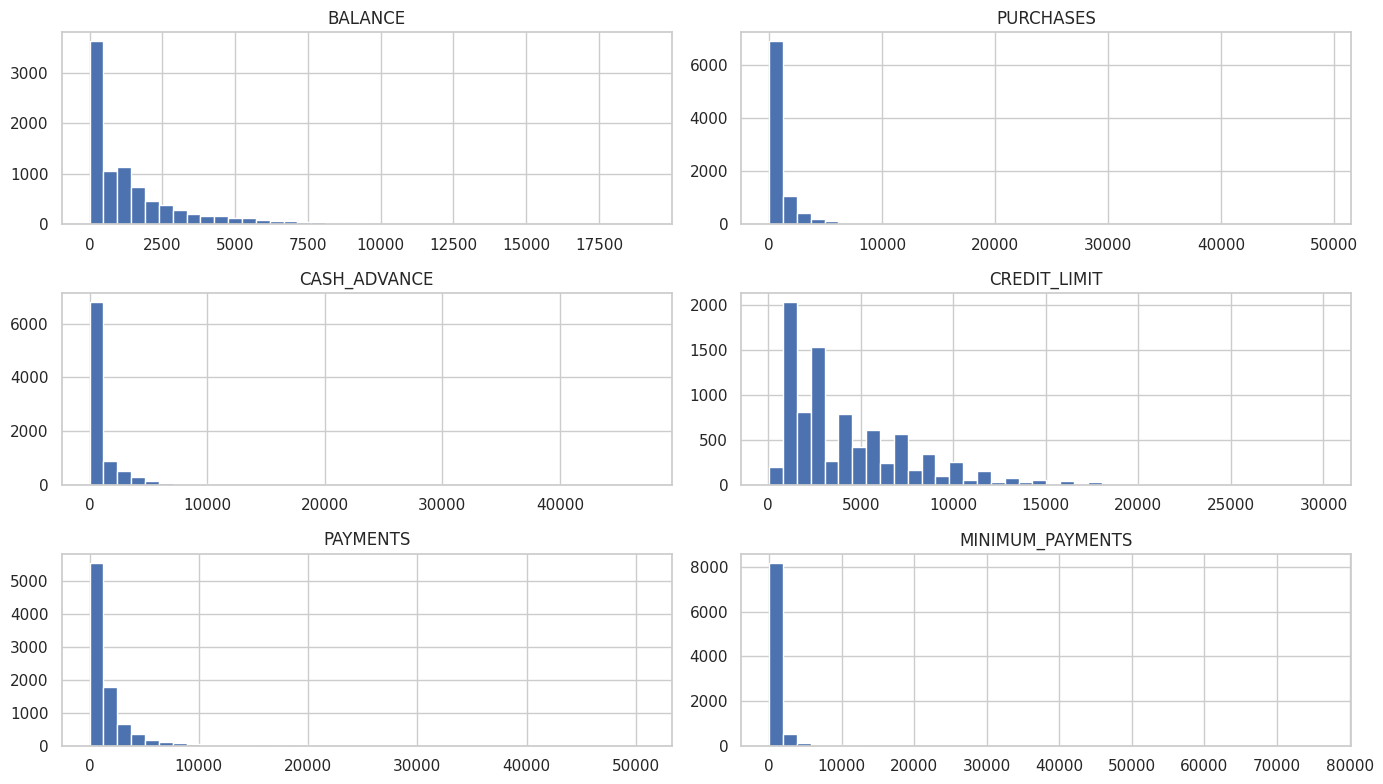

In [8]:
cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']
df[cols].hist(bins=40, figsize=(14, 8))
plt.tight_layout()
plt.show()


### Escalado

K-Means, PCA y casi todos los algoritmos de distancia son **sensibles a la escala**. `CREDIT_LIMIT` llega a miles y `PURCHASES_FREQUENCY` está entre 0 y 1: sin escalar, las variables grandes dominarían. Estandarizamos (media 0, desviación 1).

In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(df)
print('X shape:', X.shape)


X shape: (8950, 17)


## PCA

Con 17 variables no podemos pintar un scatter directo. Usamos PCA para (1) ver cuánta información retiene cada componente y (2) proyectar a 2D.

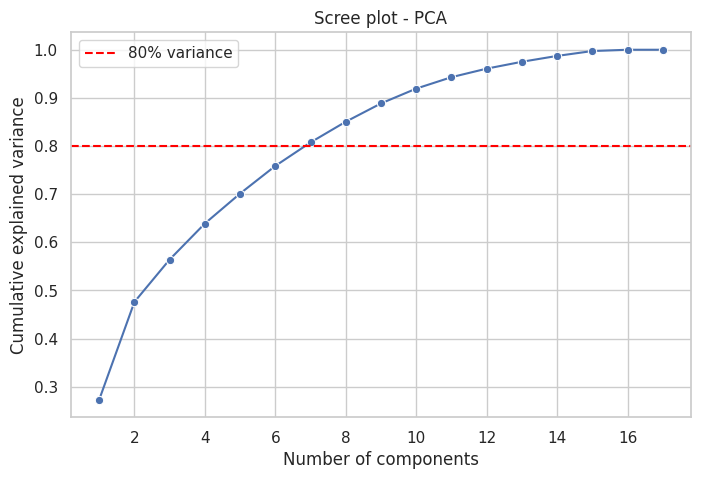

Components needed to retain ~80% of variance: 7


In [10]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
sns.lineplot(x=range(1, len(cumulative_variance) + 1), y=cumulative_variance, marker='o')
plt.axhline(0.8, color='red', linestyle='--', label='80% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('Scree plot - PCA')
plt.legend()
plt.show()

n_comp_80 = int(np.argmax(cumulative_variance >= 0.8) + 1)
print(f'Components needed to retain ~80% of variance: {n_comp_80}')


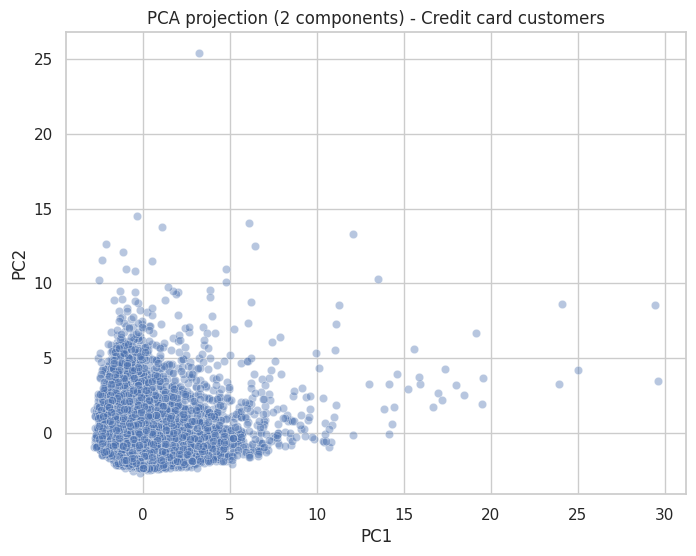

In [11]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], alpha=0.4)
plt.title('PCA projection (2 components) - Credit card customers')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


A diferencia de las setas, aquí no vemos grupos separados a simple vista: es más bien una **nube continua**. El clustering nos ayudará a trazar fronteras útiles dentro de ella.

## Clustering: ¿cuántos segmentos? Codo + Silhouette

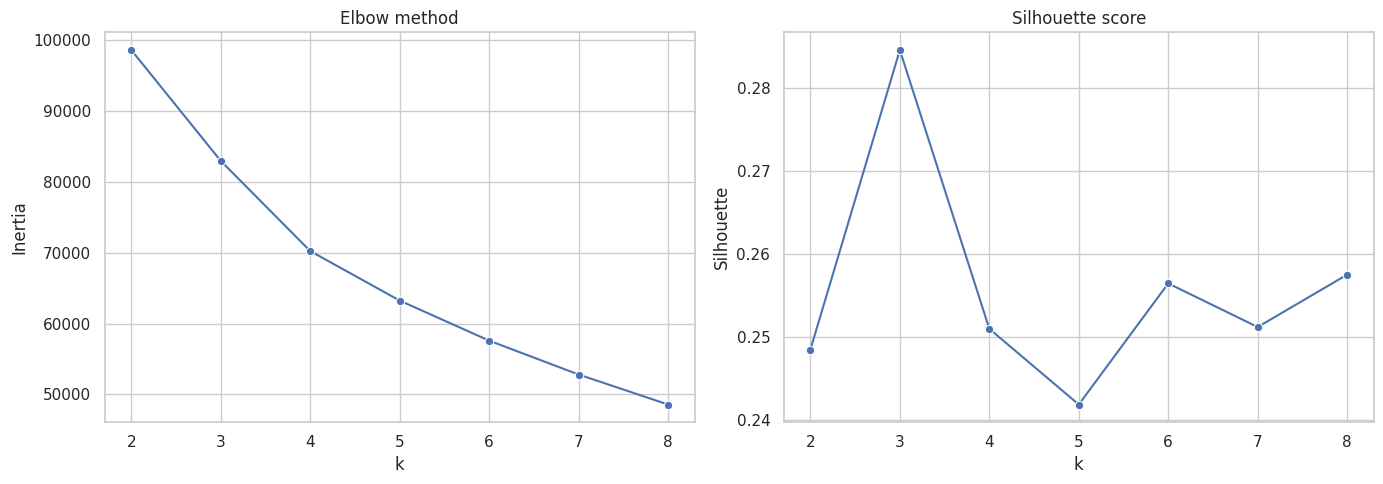

Best k according to silhouette: 3


In [12]:
pca_clust = PCA(n_components=n_comp_80, random_state=RANDOM_STATE)
X_red = pca_clust.fit_transform(X)

k_values = range(2, 9)
inertias, silhouettes = [], []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_red)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_red, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(x=list(k_values), y=inertias, marker='o', ax=axes[0])
axes[0].set_title('Elbow method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

sns.lineplot(x=list(k_values), y=silhouettes, marker='o', ax=axes[1])
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

best_k = list(k_values)[int(np.argmax(silhouettes))]
print(f'Best k according to silhouette: {best_k}')


### K-Means final

In [13]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_red)

df['cluster'] = cluster_labels
print(df['cluster'].value_counts().sort_index())


cluster
0    1568
1    6132
2    1250
Name: count, dtype: int64


### Comparativa de algoritmos

Sin etiqueta, comparamos con **métricas internas**: *silhouette* y *Calinski-Harabasz* (más alto = mejor) y *Davies-Bouldin* (más bajo = mejor).

In [14]:
def evaluate(name, labels, X):
    labels = np.asarray(labels)
    mask = labels != -1
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        sil, db, ch = np.nan, np.nan, np.nan
    else:
        sil = silhouette_score(X[mask], labels[mask])
        db = davies_bouldin_score(X[mask], labels[mask])
        ch = calinski_harabasz_score(X[mask], labels[mask])
    return {'Algorithm': name, 'Silhouette': sil, 'Davies-Bouldin': db, 'Calinski-Harabasz': ch}

results = []

results.append(evaluate('K-Means', cluster_labels, X_red))

agg = AgglomerativeClustering(n_clusters=best_k).fit(X_red)
results.append(evaluate('Agglomerative', agg.labels_, X_red))

gmm = GaussianMixture(n_components=best_k, random_state=RANDOM_STATE).fit(X_red)
gmm_labels = gmm.predict(X_red)
results.append(evaluate('GMM', gmm_labels, X_red))

df_results = pd.DataFrame(results)
df_results


,Algorithm,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,0.284553,1.358740,2150.350977
1,Agglomerative,0.201642,1.572155,1732.592959
2,GMM,0.135609,2.062110,1268.833712


### Dendrograma

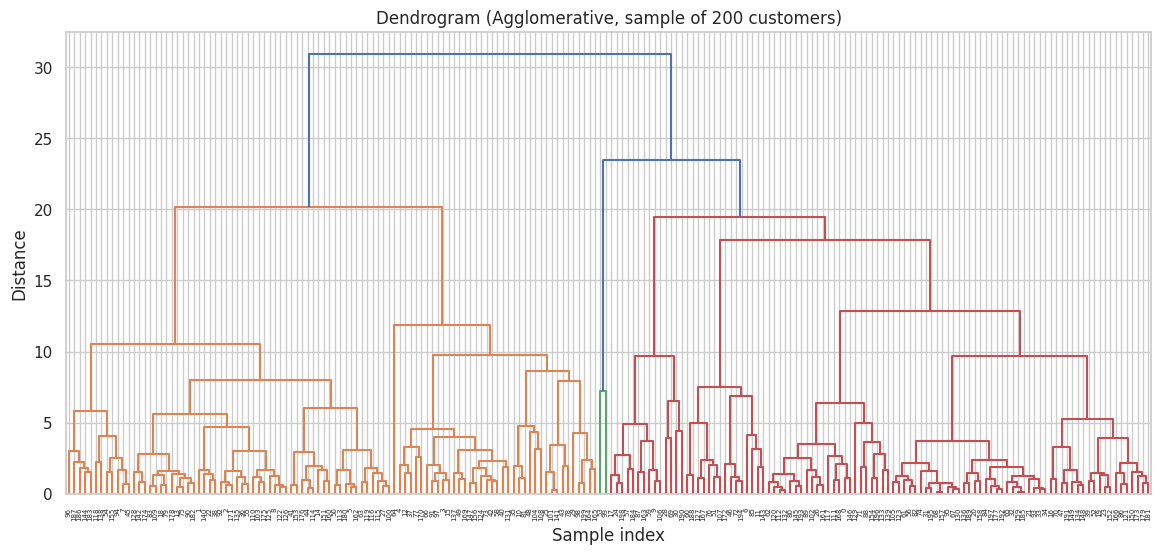

In [15]:
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(X_red.shape[0], size=200, replace=False)
X_dendro = X_red[sample_idx]

Z = linkage(X_dendro, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z)
plt.title('Dendrogram (Agglomerative, sample of 200 customers)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()


### DBSCAN: ¿hay clusters de densidad aquí?

Probamos DBSCAN. Veréis que en alta dimensión tiende a juntar casi todo en **un solo cluster** y marcar el resto como **ruido**. Eso nos dice algo importante: estos datos son una nube continua, no grupos separados por densidad. Aquí DBSCAN funciona mejor como **detector de atípicos** que como segmentador.

DBSCAN on PCA(2): 1 clusters, 59 points marked as noise (0.7%)


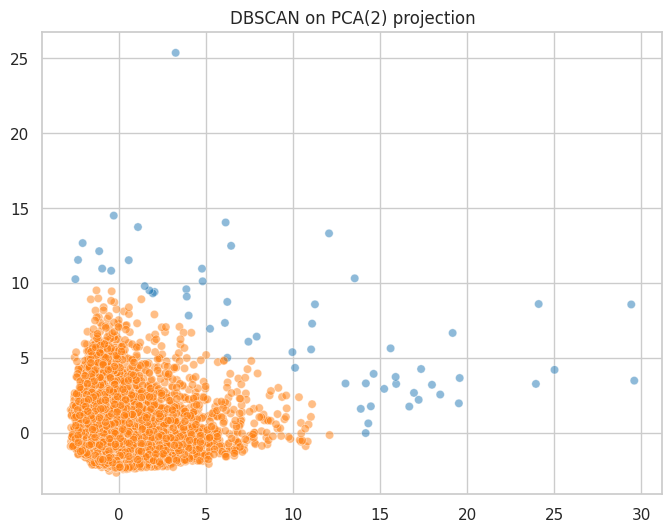

In [16]:
dbscan = DBSCAN(eps=1.5, min_samples=15).fit(X_pca2)
n_clusters_db = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_noise = (dbscan.labels_ == -1).sum()
print(f'DBSCAN on PCA(2): {n_clusters_db} clusters, {n_noise} points marked as noise ({n_noise / len(dbscan.labels_) * 100:.1f}%)')

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], hue=dbscan.labels_, palette='tab10', alpha=0.5, legend=False)
plt.title('DBSCAN on PCA(2) projection')
plt.show()


### Visualización de los segmentos (t-SNE)

Proyectamos con t-SNE (sobre una muestra) y coloreamos por el segmento de K-Means.

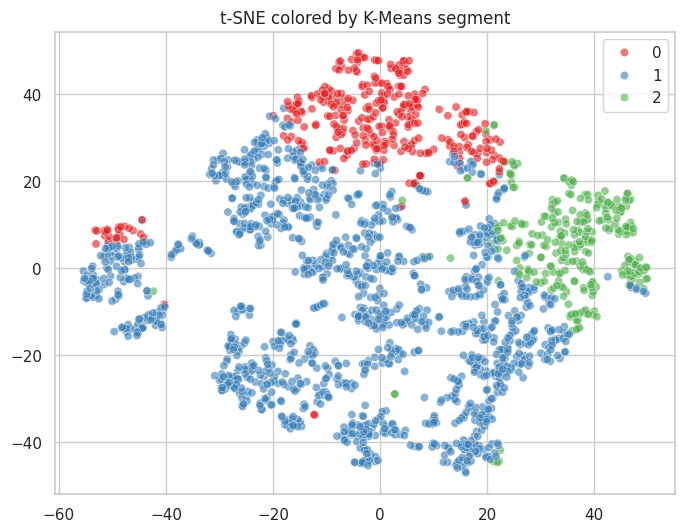

In [17]:
sample_size = 2000
sample_idx2 = rng.choice(X_red.shape[0], size=min(sample_size, X_red.shape[0]), replace=False)
X_sample = X_red[sample_idx2]
cluster_sample = cluster_labels[sample_idx2]

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init='pca', perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=cluster_sample, palette='Set1', alpha=0.6)
plt.title('t-SNE colored by K-Means segment')
plt.show()


## Interpretación de los segmentos

Lo más importante en segmentación: **¿qué caracteriza a cada grupo?** Calculamos la media de cada variable por cluster y la estandarizamos entre clusters (rojo = por encima de la media, azul = por debajo). Así leemos el «perfil» de cada segmento.

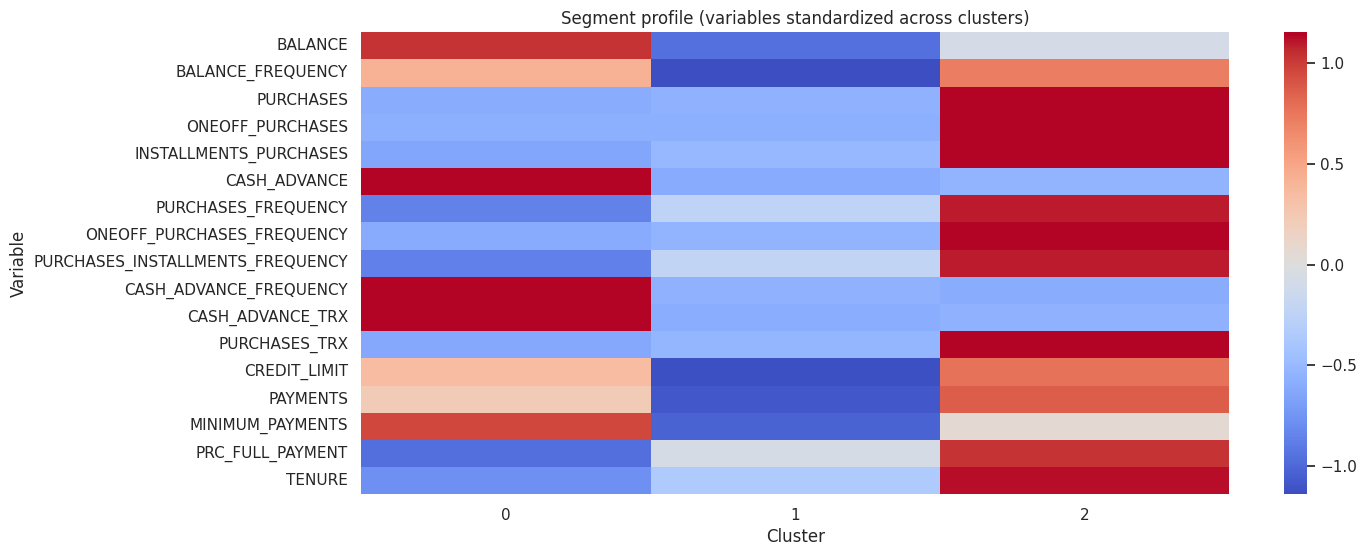

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,4009.644700,0.957771,390.361307,249.340395,141.099783,3928.214190,0.235308,0.112334,0.146857,0.449467,12.571429,5.762117,6727.585807,3062.738441,1778.965349,0.033745,11.350765
1,806.001630,0.835473,498.327888,248.258364,250.389641,332.794233,0.462543,0.131456,0.343291,0.069667,1.234508,8.599641,3266.752052,905.491823,530.273815,0.154341,11.478637
2,2218.019859,0.981336,4248.680096,2711.222752,1537.937344,448.609896,0.946690,0.663815,0.741107,0.062064,1.436000,55.908000,7714.600000,4125.430193,1216.687091,0.301133,11.916000


In [18]:
profile = df.groupby('cluster').mean(numeric_only=True)

profile_z = (profile - profile.mean()) / profile.std()

plt.figure(figsize=(14, 6))
sns.heatmap(profile_z.T, cmap='coolwarm', center=0, annot=False)
plt.title('Segment profile (variables standardized across clusters)')
plt.xlabel('Cluster')
plt.ylabel('Variable')
plt.show()

profile


#### Naming the segments in business terms

With the three clusters found (k=3 according to silhouette) and each cluster's mean profile:

- **Cluster 0 (1,568 customers, ~17.5%) — Risk / heavy credit usage**: higher average balance (~4,010), very high cash advance usage (CASH_ADVANCE ~3,928, frequency ~0.45) and low purchase frequency (~0.24). These customers rely on cash advances rather than card purchases for liquidity: a higher-risk credit profile, candidates for limit review or refinancing offers.
- **Cluster 1 (6,132 customers, ~68.5%) — Low profile / limited activity**: the majority group. Low balance (~806), moderate purchases and minimal cash advance usage. This is the core customer base with modest activity; the natural target for activation campaigns and cashback incentives on early purchases.
- **Cluster 2 (1,250 customers, ~14%) — VIP / high value**: very high purchases (~4,249, with ~2,711 in one-off purchases), near-maximum purchase frequency (~0.95) and the highest transaction count (~56). This is the highest-value segment: loyalty programs, credit limit increases and premium benefits to retain them.

This segmentation is the business deliverable of the case: it turns the statistical clusters into three differentiated marketing strategies.


Leyendo el heatmap se pueden nombrar los segmentos en términos de **negocio**, por ejemplo: clientes de alto saldo y muchas compras (VIP), clientes que tiran de adelantos de efectivo (riesgo), clientes poco activos, etc. Ese nombre y la estrategia asociada es justo el entregable que pide el caso.

## Detección de anomalías (Isolation Forest)

Identificamos los clientes con comportamiento más atípico (posible fraude, errores de datos o clientes premium fuera de norma).

Anomalies detected: 448 out of 8950 (5.01%)


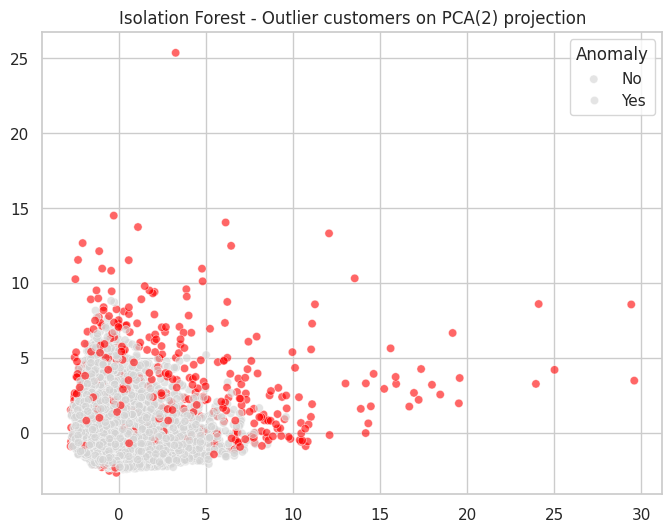

In [19]:
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
anomaly_labels = iso.fit_predict(X_red)  # -1 = anomaly

print(f'Anomalies detected: {(anomaly_labels == -1).sum()} out of {len(anomaly_labels)} ({(anomaly_labels == -1).mean() * 100:.2f}%)')

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca2[:, 0], y=X_pca2[:, 1],
    hue=(anomaly_labels == -1), palette={True: 'red', False: 'lightgray'}, alpha=0.6
)
plt.title('Isolation Forest - Outlier customers on PCA(2) projection')
plt.legend(title='Anomaly', labels=['No', 'Yes'])
plt.show()


---
## Para ir más allá (opcional)

- **Ingeniería de KPIs**: derivar variables como *ratio de uso del límite* (`BALANCE / CREDIT_LIMIT`) o *compra media por transacción* suele mejorar mucho los segmentos.
- **UMAP / HDBSCAN** para visualización y clustering por densidad más robusto.
- **Transformación logarítmica** de las variables sesgadas antes de escalar.

## Conclusiones

- Sin etiqueta, la segmentación se valida con métricas internas (*silhouette*, etc.) y, sobre todo, con la **interpretabilidad** de los perfiles.
- Imputar y **escalar** fue imprescindible aquí (a diferencia de las setas).
- K-Means, GMM y Aglomerativo dan segmentos coherentes; DBSCAN reveló que los datos son una nube continua (mejor como detector de atípicos).
- El heatmap de perfiles convierte los clusters en **segmentos de negocio accionables**.